# 1. Kerjakan soal yang ada di link ini:
 Untuk NIM dengan nomor urut 11-20 mengerjakan studi kasus 2
https://polibatam.id/StudiKasus2_ML

# Supervised Learning

## Classification - Dataset Karyawan

### Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [2]:
train = pd.read_csv('dataset_karyawan_missing.csv')
train.head()

,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,NaN,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               200 non-null    int64  
 1   Nama             200 non-null    object 
 2   Departemen       190 non-null    object 
 3   Gaji             190 non-null    float64
 4   Usia             200 non-null    int64  
 5   Lama_Kerja       200 non-null    int64  
 6   Status_Karyawan  200 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 11.1+ KB


In [4]:
d = train.describe()
d

,ID,Gaji,Usia,Lama_Kerja
count,200.000000,1.900000e+02,200.000000,200.000000
mean,100.500000,5.053853e+06,41.545000,14.455000
std,57.879185,7.778678e+05,10.367517,8.277716
min,1.000000,2.786682e+06,22.000000,0.000000
25%,50.750000,4.594828e+06,34.000000,7.750000
50%,100.500000,5.040414e+06,42.000000,15.000000
75%,150.250000,5.602506e+06,49.250000,21.000000
max,200.000000,6.941904e+06,59.000000,29.000000


C:\Users\Acer\AppData\Local\Temp\ipykernel_10804\72597282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status_Karyawan', data=train, palette='RdBu_r')


<Axes: xlabel='Status_Karyawan', ylabel='count'>

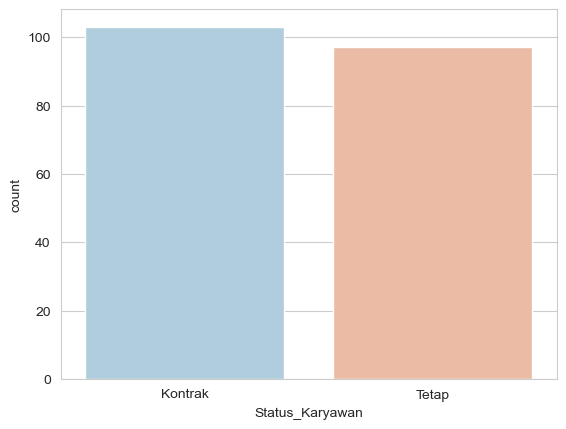

In [5]:
# Cek relative size dari Status_Karyawan Tetap dan Kontrak
sns.set_style('whitegrid')
sns.countplot(x='Status_Karyawan', data=train, palette='RdBu_r')

<Axes: xlabel='Status_Karyawan', ylabel='count'>

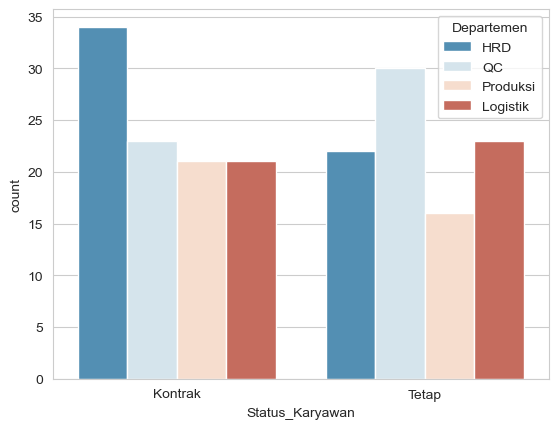

In [6]:
# Status_Karyawan vs Departemen
sns.set_style('whitegrid')
sns.countplot(x='Status_Karyawan', hue='Departemen', data=train, palette='RdBu_r')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'HRD'),
  Text(1, 0, 'Logistik'),
  Text(2, 0, 'Produksi'),
  Text(3, 0, 'QC')])

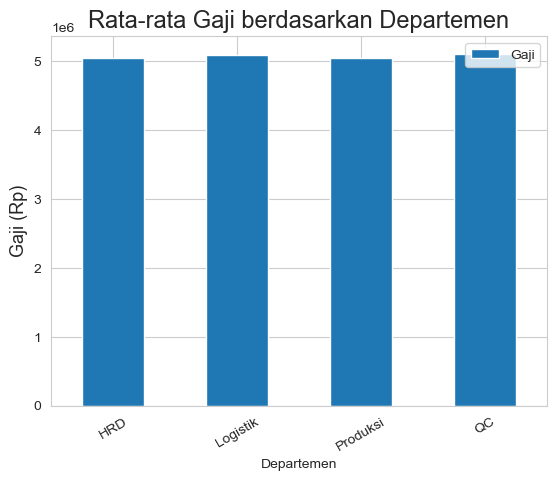

In [7]:
# Rata-rata Gaji berdasarkan Departemen
f_dept_gaji = train.groupby('Departemen')['Gaji'].mean()
f_dept_gaji = pd.DataFrame(f_dept_gaji)
f_dept_gaji.plot.bar(y='Gaji')
plt.title("Rata-rata Gaji berdasarkan Departemen", fontsize=17)
plt.ylabel("Gaji (Rp)", fontsize=13)
plt.xticks(rotation=30)

C:\Users\Acer\AppData\Local\Temp\ipykernel_10804\2154273331.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Status_Karyawan', y='Lama_Kerja', data=train, palette='rainbow')


Text(0.5, 1.0, 'Distribusi Lama Kerja per Status Karyawan')

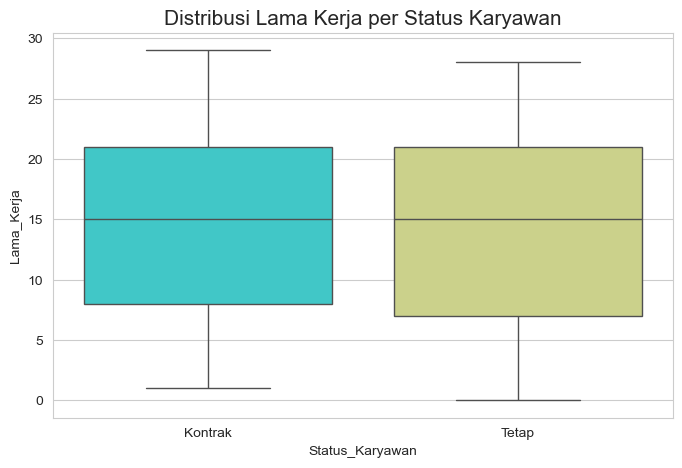

In [8]:
# Status_Karyawan vs Lama_Kerja (box plot)
sns.set_style('whitegrid')
plt.figure(figsize=(8, 5))
sns.boxplot(x='Status_Karyawan', y='Lama_Kerja', data=train, palette='rainbow')
plt.title("Distribusi Lama Kerja per Status Karyawan", fontsize=15)

<Axes: title={'center': 'Histogram Usia Karyawan'}, xlabel='Usia Karyawan', ylabel='Count'>

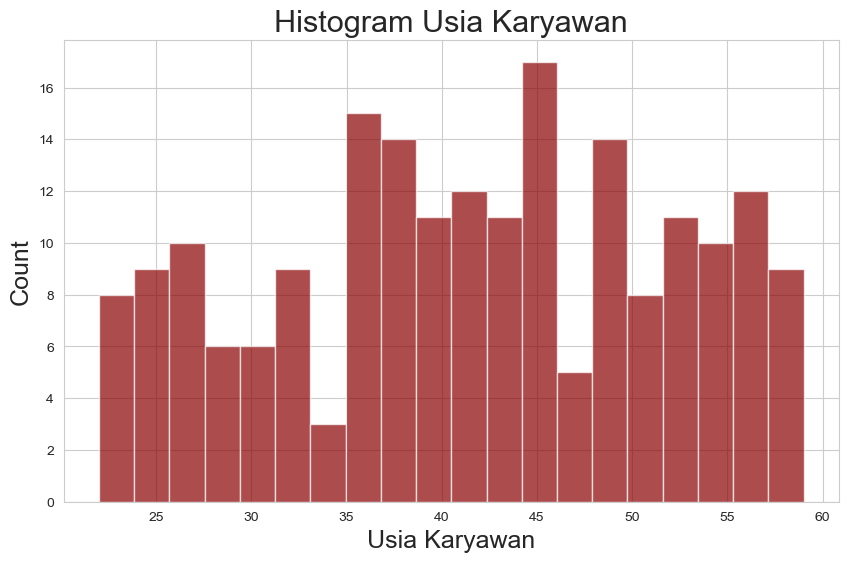

In [9]:
# Cek distribusi dari Usia
plt.xlabel("Usia Karyawan", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram Usia Karyawan", fontsize=22)
train['Usia'].hist(bins=20, color='darkred', alpha=0.7, figsize=(10, 6))

C:\Users\Acer\AppData\Local\Temp\ipykernel_10804\3764199355.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Departemen', y='Usia', data=train, palette='winter')


<Axes: xlabel='Departemen', ylabel='Usia'>

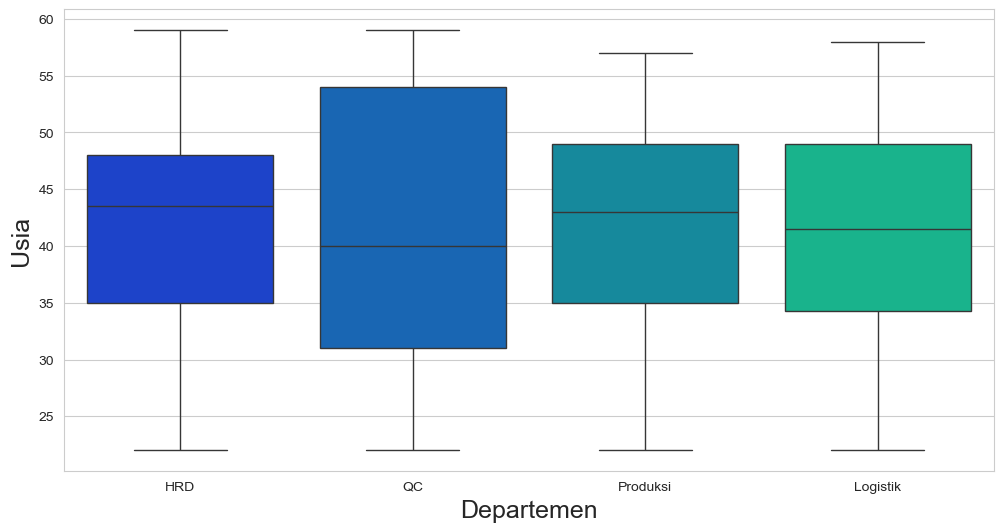

In [10]:
# Distribusi Usia di setiap Departemen
plt.figure(figsize=(12, 6))
plt.xlabel("Departemen", fontsize=18)
plt.ylabel("Usia", fontsize=18)
sns.boxplot(x='Departemen', y='Usia', data=train, palette='winter')

(array([0, 1, 2, 3]),
 [Text(0, 0, 'HRD'),
  Text(1, 0, 'Logistik'),
  Text(2, 0, 'Produksi'),
  Text(3, 0, 'QC')])

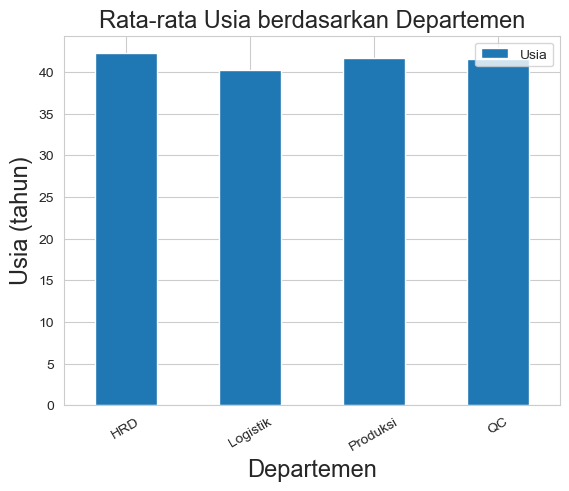

In [11]:
f_dept_usia = train.groupby('Departemen')['Usia'].mean()
f_dept_usia = pd.DataFrame(f_dept_usia)
f_dept_usia.plot.bar(y='Usia')
plt.title("Rata-rata Usia berdasarkan Departemen", fontsize=17)
plt.ylabel("Usia (tahun)", fontsize=17)
plt.xlabel("Departemen", fontsize=17)
plt.xticks(rotation=30)

# Fitur Engineering

In [12]:
# Cek missing values
print("Missing Values per Kolom:")
print(train.isnull().sum())

Missing Values per Kolom:
ID                  0
Nama                0
Departemen         10
Gaji               10
Usia                0
Lama_Kerja          0
Status_Karyawan     0
dtype: int64


In [13]:
# Dataset memiliki missing value pada kolom Departemen dan Gaji
# Imputasi: Departemen -> modus, Gaji -> median
train['Departemen'].fillna(train['Departemen'].mode()[0], inplace=True)
train['Gaji'].fillna(train['Gaji'].median(), inplace=True)

print("Missing values setelah imputasi:")
print(train.isnull().sum())

Missing values setelah imputasi:
ID                 0
Nama               0
Departemen         0
Gaji               0
Usia               0
Lama_Kerja         0
Status_Karyawan    0
dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_10804\3934107160.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Departemen'].fillna(train['Departemen'].mode()[0], inplace=True)
C:\Users\Acer\AppData\Local\Temp\ipykernel_10804\3934107160.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

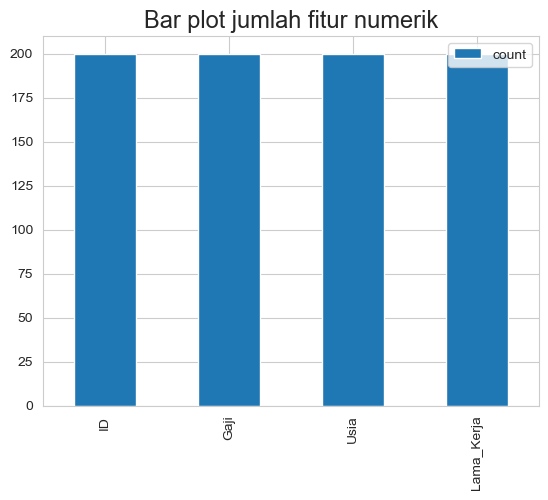

In [14]:
d = train.describe()
dT = d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik", fontsize=17)

In [15]:
# Drop baris jika masih ada null (setelah imputasi seharusnya tidak ada)
train.dropna(inplace=True)
train.head()

,ID,Nama,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,1,Citra,HRD,5744870.0,53,9,Kontrak
1,2,Eka,HRD,5862014.0,39,9,Tetap
2,3,Citra,HRD,4894992.0,55,16,Tetap
3,4,Budi,QC,4606286.0,51,2,Kontrak
4,5,Dewi,HRD,4199766.0,44,7,Kontrak


In [16]:
# Drop kolom ID dan Nama karena tidak relevan sebagai fitur prediksi
train.drop(columns=['ID', 'Nama'], inplace=True)
train.head()

,Departemen,Gaji,Usia,Lama_Kerja,Status_Karyawan
0,HRD,5744870.0,53,9,Kontrak
1,HRD,5862014.0,39,9,Tetap
2,HRD,4894992.0,55,16,Tetap
3,QC,4606286.0,51,2,Kontrak
4,HRD,4199766.0,44,7,Kontrak


In [17]:
# Encoding kolom kategorikal
# Departemen -> One-Hot Encoding
# Status_Karyawan (target) -> Label Encoding: Kontrak=0, Tetap=1
from sklearn.preprocessing import LabelEncoder

train = pd.get_dummies(train, columns=['Departemen'], drop_first=False)

le = LabelEncoder()
train['Status_Karyawan'] = le.fit_transform(train['Status_Karyawan'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
train.head()

Label mapping: {'Kontrak': np.int64(0), 'Tetap': np.int64(1)}


,Gaji,Usia,Lama_Kerja,Status_Karyawan,Departemen_HRD,Departemen_Logistik,Departemen_Produksi,Departemen_QC
0,5744870.0,53,9,0,True,False,False,False
1,5862014.0,39,9,1,True,False,False,False
2,4894992.0,55,16,1,True,False,False,False
3,4606286.0,51,2,0,False,False,False,True
4,4199766.0,44,7,0,True,False,False,False


### Training

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    train.drop('Status_Karyawan', axis=1),
    train['Status_Karyawan'],
    test_size=0.30,
    random_state=42
)

In [19]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (140, 7)
Test shape: (60, 7)


# **KNN**

In [20]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = clf1.predict(X_test)

### Evaluation

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Akurasi Model KNN: 0.58
Confusion Matrix:
[[18 12]
 [13 17]]
Classification Report:
              precision    recall  f1-score   support

     Kontrak       0.58      0.60      0.59        30
       Tetap       0.59      0.57      0.58        30

    accuracy                           0.58        60
   macro avg       0.58      0.58      0.58        60
weighted avg       0.58      0.58      0.58        60



# **Naive Bayes**

In [23]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediksi data uji
y_pred_nb = nb.predict(X_test)

### Evaluation

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_nb)
print(f'Akurasi Model Naive Bayes: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

Akurasi Model Naive Bayes: 0.48
Confusion Matrix:
[[24  6]
 [25  5]]
Classification Report:
              precision    recall  f1-score   support

     Kontrak       0.49      0.80      0.61        30
       Tetap       0.45      0.17      0.24        30

    accuracy                           0.48        60
   macro avg       0.47      0.48      0.43        60
weighted avg       0.47      0.48      0.43        60



# **Decision Tree**

In [25]:
from sklearn.tree import DecisionTreeClassifier

# Inisialisasi dan latih model Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Prediksi data uji
y_pred_dt = dt.predict(X_test)

### Evaluation

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Akurasi Model Decision Tree: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

Akurasi Model Decision Tree: 0.55
Confusion Matrix:
[[19 11]
 [16 14]]
Classification Report:
              precision    recall  f1-score   support

     Kontrak       0.54      0.63      0.58        30
       Tetap       0.56      0.47      0.51        30

    accuracy                           0.55        60
   macro avg       0.55      0.55      0.55        60
weighted avg       0.55      0.55      0.55        60



Setelah membandingkan ketiga model, kita pilih model dengan evaluasi terbaik untuk prediksi data baru menggunakan Naive Bayes

In [27]:
# Data karyawan baru
# Format: [Gaji, Usia, Lama_Kerja, Departemen_HRD, Departemen_Logistik, Departemen_Produksi, Departemen_QC]
feature_cols = X_train.columns.tolist()
print("Urutan fitur:", feature_cols)

# Contoh: Karyawan usia 40, gaji 5.5jt, lama kerja 10 tahun, departemen HRD
new_data = np.array([[5500000, 40, 10, 1, 0, 0, 0]])

# Prediksi kelas
new_prediction = nb.predict(new_data)
print("Prediksi Status (0 = Kontrak, 1 = Tetap):", new_prediction[0])
print("Status:", le.inverse_transform(new_prediction)[0])

# Prediksi probabilitas
proba = nb.predict_proba(new_data)
print("Probabilitas Prediksi [Kontrak, Tetap]:", proba[0])

Urutan fitur: ['Gaji', 'Usia', 'Lama_Kerja', 'Departemen_HRD', 'Departemen_Logistik', 'Departemen_Produksi', 'Departemen_QC']
Prediksi Status (0 = Kontrak, 1 = Tetap): 0
Status: Kontrak
Probabilitas Prediksi [Kontrak, Tetap]: [0.5490289 0.4509711]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(



# **Contoh Penggunaan Parameter**

In [28]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred_knn = clf2.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

Akurasi Model KNN: 0.52
Confusion Matrix:
[[17 13]
 [16 14]]
Classification Report:
              precision    recall  f1-score   support

     Kontrak       0.52      0.57      0.54        30
       Tetap       0.52      0.47      0.49        30

    accuracy                           0.52        60
   macro avg       0.52      0.52      0.52        60
weighted avg       0.52      0.52      0.52        60



### Contoh penggunaan Model KNN dengan GridSearchCV

In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy' : make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall'   : make_scorer(recall_score, average='macro'),
    'f1'       : make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.657143   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.650000   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.621429   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.621429   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.607143   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.600000   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.592857   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.592857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.592857   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.585714   
7   {'metric': 'manhattan', 'n_neighbors

In [31]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")

Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [32]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}


In [33]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.58
Presisi:  0.58
Recall:   0.58
F1-Score: 0.58

Classification Report:
              precision    recall  f1-score   support

     Kontrak       0.58      0.60      0.59        30
       Tetap       0.59      0.57      0.58        30

    accuracy                           0.58        60
   macro avg       0.58      0.58      0.58        60
weighted avg       0.58      0.58      0.58        60

Confusion Matrix:
[[18 12]
 [13 17]]


In [34]:
import numpy as np

# Data karyawan baru (urutan fitur sama seperti X_train)
# [Gaji, Usia, Lama_Kerja, Departemen_HRD, Departemen_Logistik, Departemen_Produksi, Departemen_QC]
new_data_1 = np.array([[5500000, 40, 10, 1, 0, 0, 0]])

# Prediksi apakah karyawan ini Tetap atau Kontrak
prediction = best_model.predict(new_data_1)

print("Prediksi (0 = Kontrak, 1 = Tetap):", prediction[0])
print("Status:", le.inverse_transform(prediction)[0])

Prediksi (0 = Kontrak, 1 = Tetap): 1
Status: Tetap


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


# **Random Forest**

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan latih model Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Prediksi data uji
y_pred_rf = rf.predict(X_test)

### Evaluation

In [36]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Akurasi Model Random Forest: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_rf))

print('Classification Report:')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Akurasi Model Random Forest: 0.58
Confusion Matrix:
[[19 11]
 [14 16]]
Classification Report:
              precision    recall  f1-score   support

     Kontrak       0.58      0.63      0.60        30
       Tetap       0.59      0.53      0.56        30

    accuracy                           0.58        60
   macro avg       0.58      0.58      0.58        60
weighted avg       0.58      0.58      0.58        60



### Feature Importance

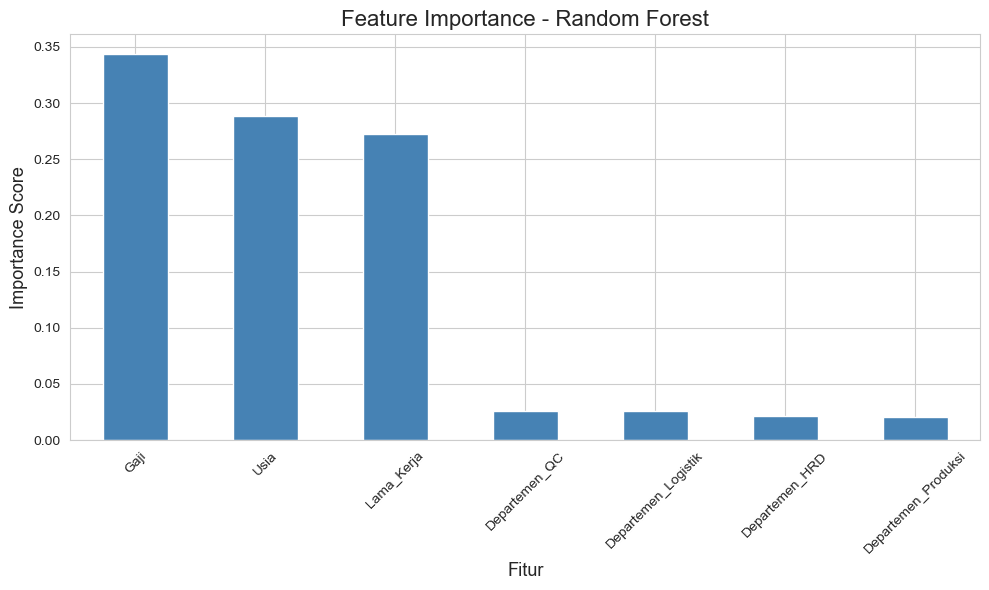


Top 5 Fitur Paling Berpengaruh:
Gaji                   0.343931
Usia                   0.288583
Lama_Kerja             0.272363
Departemen_QC          0.026308
Departemen_Logistik    0.026045
dtype: float64


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Visualisasi Feature Importance
feature_names = X_train.columns
importances = rf.feature_importances_

fi_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
fi_df.plot(kind='bar', color='steelblue')
plt.title('Feature Importance - Random Forest', fontsize=16)
plt.xlabel('Fitur', fontsize=13)
plt.ylabel('Importance Score', fontsize=13)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('\nTop 5 Fitur Paling Berpengaruh:')
print(fi_df.head())

### Prediksi Data Baru

In [38]:
import numpy as np

# Data karyawan baru
# Format: [Gaji, Usia, Lama_Kerja, Departemen_HRD, Departemen_Logistik, Departemen_Produksi, Departemen_QC]
print("Urutan fitur:", X_train.columns.tolist())

# Contoh: Karyawan gaji 6jt, usia 45, lama kerja 15 tahun, departemen Produksi
new_data = np.array([[6000000, 45, 15, 0, 0, 1, 0]])

# Prediksi kelas
new_prediction = rf.predict(new_data)
print('Prediksi Status (0 = Kontrak, 1 = Tetap):', new_prediction[0])
print('Status:', le.inverse_transform(new_prediction)[0])

# Prediksi probabilitas
proba = rf.predict_proba(new_data)
print('Probabilitas Prediksi [Kontrak, Tetap]:', proba[0])

Urutan fitur: ['Gaji', 'Usia', 'Lama_Kerja', 'Departemen_HRD', 'Departemen_Logistik', 'Departemen_Produksi', 'Departemen_QC']
Prediksi Status (0 = Kontrak, 1 = Tetap): 0
Status: Kontrak
Probabilitas Prediksi [Kontrak, Tetap]: [0.82 0.18]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


# **Perbandingan Semua Model**

                  Accuracy  Precision  Recall  F1-Score
Model                                                  
KNN (GridSearch)    0.5833     0.5834  0.5833    0.5832
Naive Bayes         0.4833     0.4722  0.4833    0.4257
Decision Tree       0.5500     0.5514  0.5500    0.5469
Random Forest       0.5833     0.5842  0.5833    0.5823


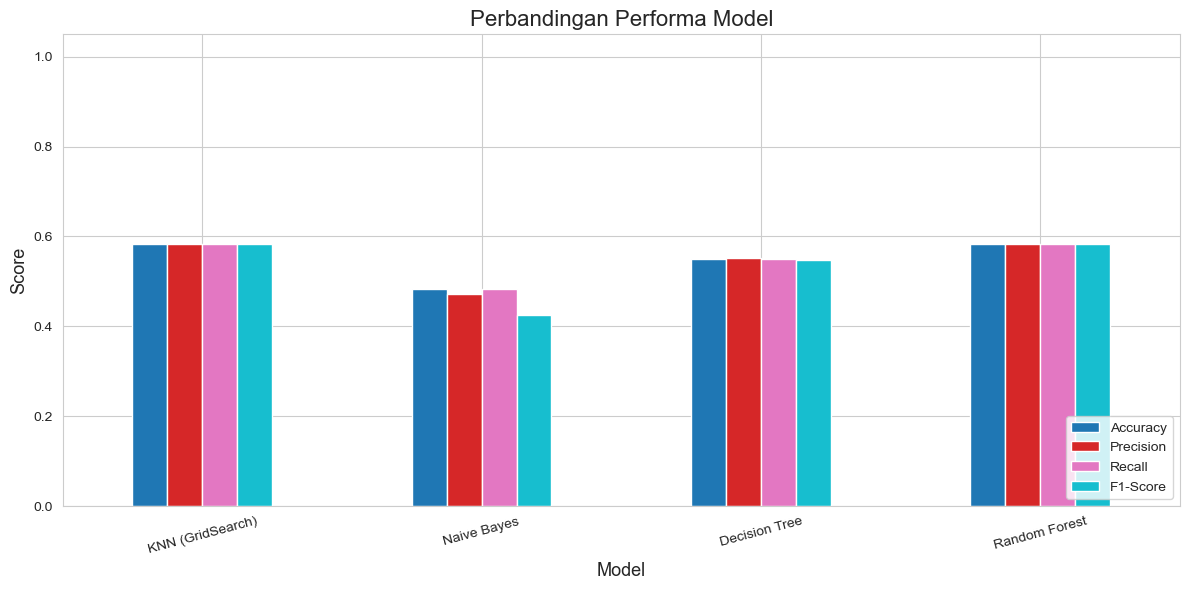

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Kumpulkan semua prediksi
results = {
    'KNN (GridSearch)': y_pred,
    'Naive Bayes'     : y_pred_nb,
    'Decision Tree'   : y_pred_dt,
    'Random Forest'   : y_pred_rf
}

rows = []
for name, pred in results.items():
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='macro'),
        'Recall'   : recall_score(y_test, pred, average='macro'),
        'F1-Score' : f1_score(y_test, pred, average='macro')
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df.round(4))

# Visualisasi perbandingan
comparison_df.plot(kind='bar', figsize=(12, 6), colormap='tab10')
plt.title('Perbandingan Performa Model', fontsize=16)
plt.ylabel('Score', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2. Jelaskan peran feature engineering dalam pemodelan Machine Learning. Jelaskan contohnya dari studi kasus masing-masing.

Feature Engineering berperan sangat penting dalam Machine Learning karena membantu mengubah data mentah menjadi data yang berkualitas dan siap digunakan oleh model. Melalui proses seperti menangani data yang hilang, mengubah data kategorikal menjadi numerik, serta menghapus fitur yang tidak relevan, Feature Engineering dapat meningkatkan akurasi model, mengurangi noise, dan membuat pola dalam data lebih mudah dipahami oleh algoritme.

#Contoh Studi kasus masing masing

- Eksplorasi & Visualisasi Data: Melakukan cek distribusi target (Status_Karyawan) menggunakan countplot serta melihat korelasi fitur melalui boxplot (Lama Kerja) dan bar plot (Gaji per Departemen).

- Penanganan Missing Values: Melakukan imputasi pada 10 nilai kosong di kolom Departemen (menggunakan modus) dan 10 nilai di kolom Gaji (menggunakan median) agar data dapat diproses oleh model.

- Transformasi Data (Encoding): Mengubah data kategorikal menjadi numerik menggunakan One-Hot Encoding untuk fitur Departemen dan Label Encoding untuk target biner Status_Karyawan.

- Pembagian Dataset: Membagi data menjadi Training Set (70%) untuk melatih model dan Test Set (30%) untuk menguji performa model.

- Pelatihan Model (Komparasi): Melatih dan membandingkan tiga algoritme berbeda, yaitu KNN, Naive Bayes, dan Decision Tree.

- Optimasi Model: Menggunakan GridSearchCV khusus pada model KNN untuk mencari kombinasi parameter terbaik (seperti jumlah neighbors dan jenis metrik jarak).

- Evaluasi Performa: Melakukan perbandingan hasil akhir menggunakan metrik Akurasi, Confusion Matrix, dan Classification Report (Presisi, Recall, F1-Score) untuk menentukan model mana yang paling akurat dalam memprediksi status karyawan.


##3. Apa itu confusion metrik dan metrik evaluasi jika dilihat dari studi kasus masing-masing,Jelaskan?

##Confusion Matrix
adalah tabel yang digunakan untuk mengukur kinerja model klasifikasi dengan membandingkan nilai prediksi model terhadap nilai sebenarnya (aktual). Pada studi kasus ini, tabel  menunjukkan detail seberapa banyak karyawan yang berhasil ditebak dengan benar atau salah untuk kategori Tetap (1) dan Kontrak (0).

#Contoh hasil pada salah satu model (KNN) di dataset tersebut:
- True Negative (TN): 18 (Karyawan Kontrak yang benar diprediksi Kontrak).
- False Positive (FP): 12 (Karyawan Kontrak yang salah diprediksi Tetap).
- False Negative (FN): 13 (Karyawan Tetap yang salah diprediksi Kontrak).
- True Positive (TP): 17 (Karyawan Tetap yang benar diprediksi Tetap).

## Metrik Evaluasi
Metrik ini adalah angka-angka statistik yang diturunkan dari Confusion Matrix untuk memberikan gambaran performa model secara menyeluruh, Contoh pada studi kasus.
# Akurasi (Accuracy)
(Accuracy): Persentase total prediksi yang benar (baik Tetap maupun Kontrak) dari keseluruhan data uji.
- Studi Kasus: Model KNN menghasilkan akurasi 0.58 (58%), yang berarti model tersebut cukup lumayan namun masih memiliki ruang besar untuk ditingkatkan.

# Presisi (Precision)
Menilai seberapa akurat model saat memprediksi label positif. Jika model memprediksi seseorang sebagai "Karyawan Tetap", seberapa besar kemungkinan ia benar-benar "Tetap".
- Studi Kasus: Model KNN memiliki presisi sekitar 0.59 untuk kategori Tetap.

# Recall (Sensitivity)
Menilai kemampuan model dalam menemukan kembali seluruh data aktual dari suatu kelas. Dari seluruh karyawan yang aslinya "Tetap", berapa banyak yang berhasil dideteksi oleh model.
- Studi Kasus: Model KNN memiliki recall 0.57 untuk kategori Tetap.

# F1-Score
Rata-rata harmonik antara Presisi dan Recall. Metrik ini berguna jika distribusi antara karyawan Tetap dan Kontrak tidak seimbang, sehingga memberikan gambaran performa yang lebih stabil.
- Studi Kasus: F1-score model KNN adalah 0.58.